<a href="https://colab.research.google.com/github/uiinlee/colab/blob/main/SAX_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Right watch data loaded: (8544, 24)
Left watch data loaded: (8559, 24)

===== Processing: Right Watch =====
Input data shape: (8544, 24)
Using parameters: {'WINDOW': 2, 'STD_QUANTILE': 0.95, 'MIN_DURATION': 10, 'VAL_THRESH': 20, 'LENGTH_THRESH': 300, 'TRIM1': 100, 'TRIM2': 20, 'SAX_PARAMS': {'WORD_LENGTH': 16, 'ALPHABET_SIZE': 12, 'SIMILARITY_THRESHOLD': 3, 'SAX_FILTER_METRIC': 'volatility', 'SAX_FILTER_THRESHOLD_GT': 15, 'SAX_FILTER_THRESHOLD_LT': 7}}
Using Acc channels: ['ACC_X(m/s^2)', 'ACC_Y', 'ACC_Z']
Using other IMU channels: ['GYR_Y', 'GYR_Z', 'Mag_X', 'Mag_Y', 'Mag_Z']
Extracting segments based on Acc channels for Right Watch...
Extracted 7 segments: [(np.int64(0), np.int64(713)), (np.int64(1160), np.int64(1856)), (np.int64(2134), np.int64(2840)), (np.int64(3110), np.int64(3892)), (np.int64(4209), np.int64(5141)), (np.int64(5496), np.int64(6212)), (np.int64(6578), np.int64(7248))]
Generated 7 unique SAX pattern groups (before filtering).

--- SAX Pattern Metrics & Filtering (Ri

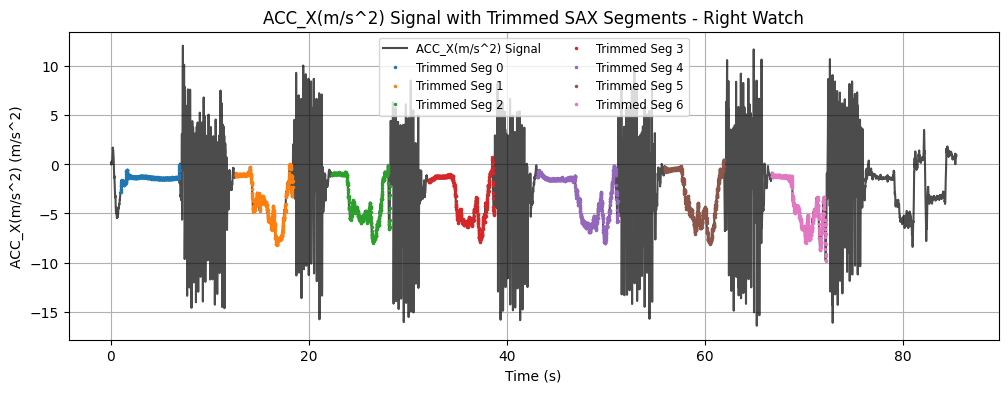

Generating IMU channel plots for Right Watch...


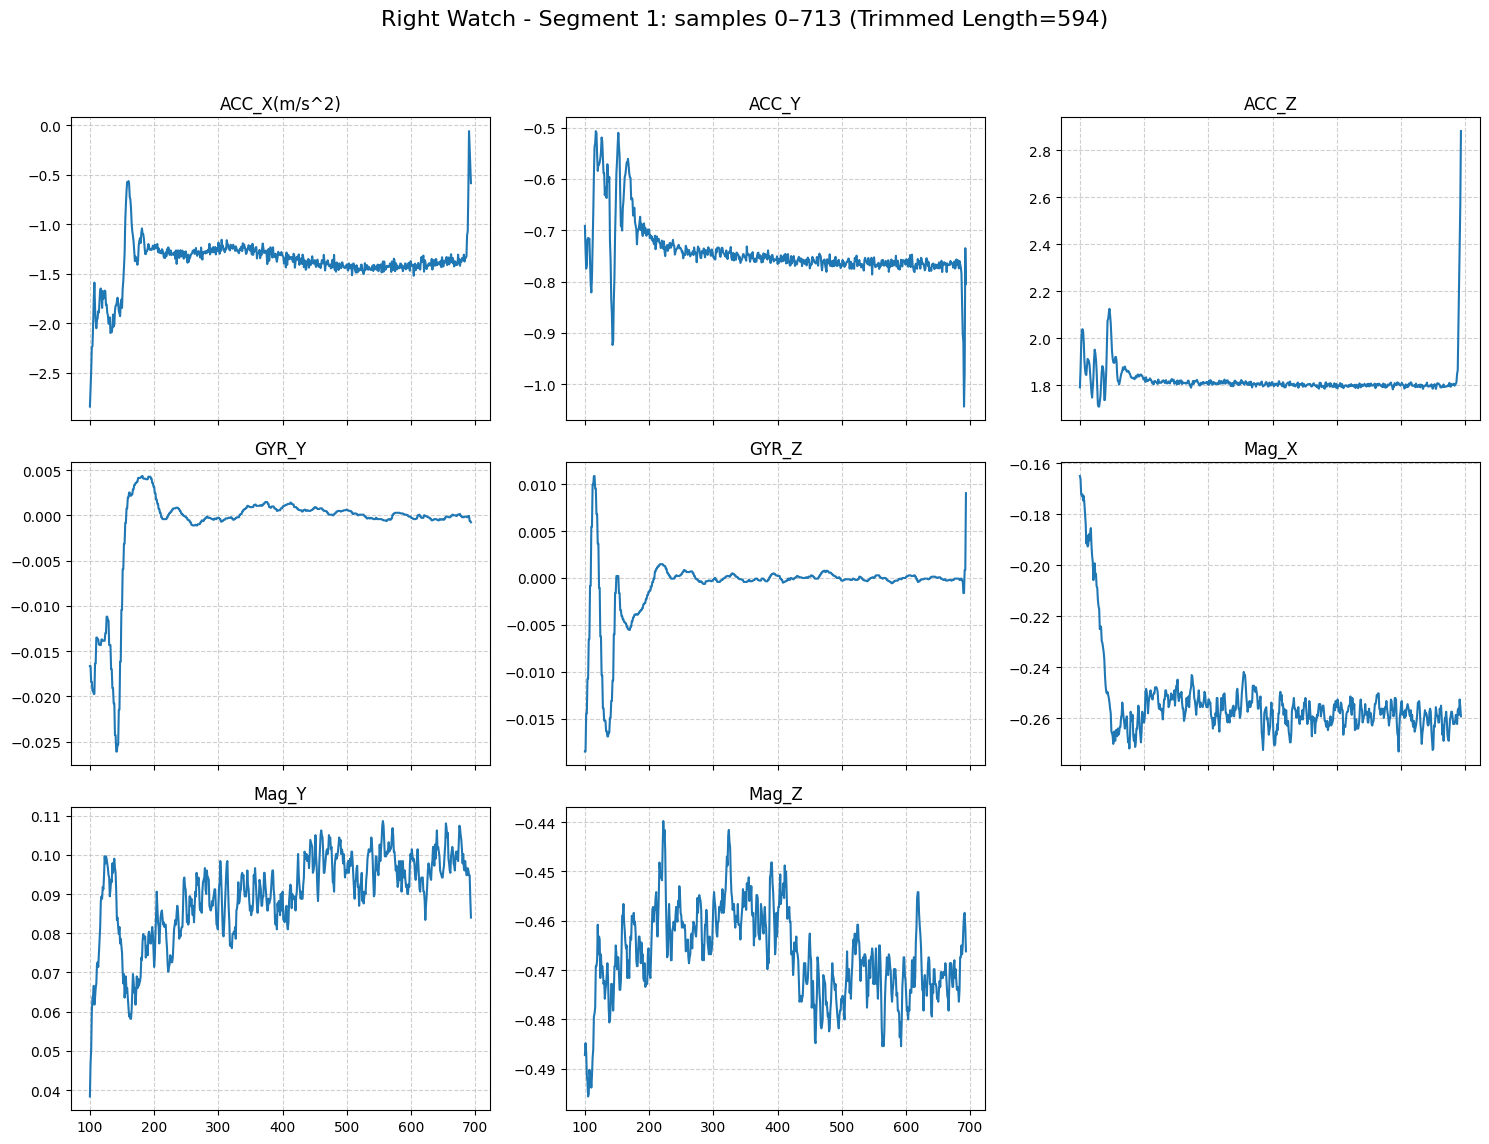

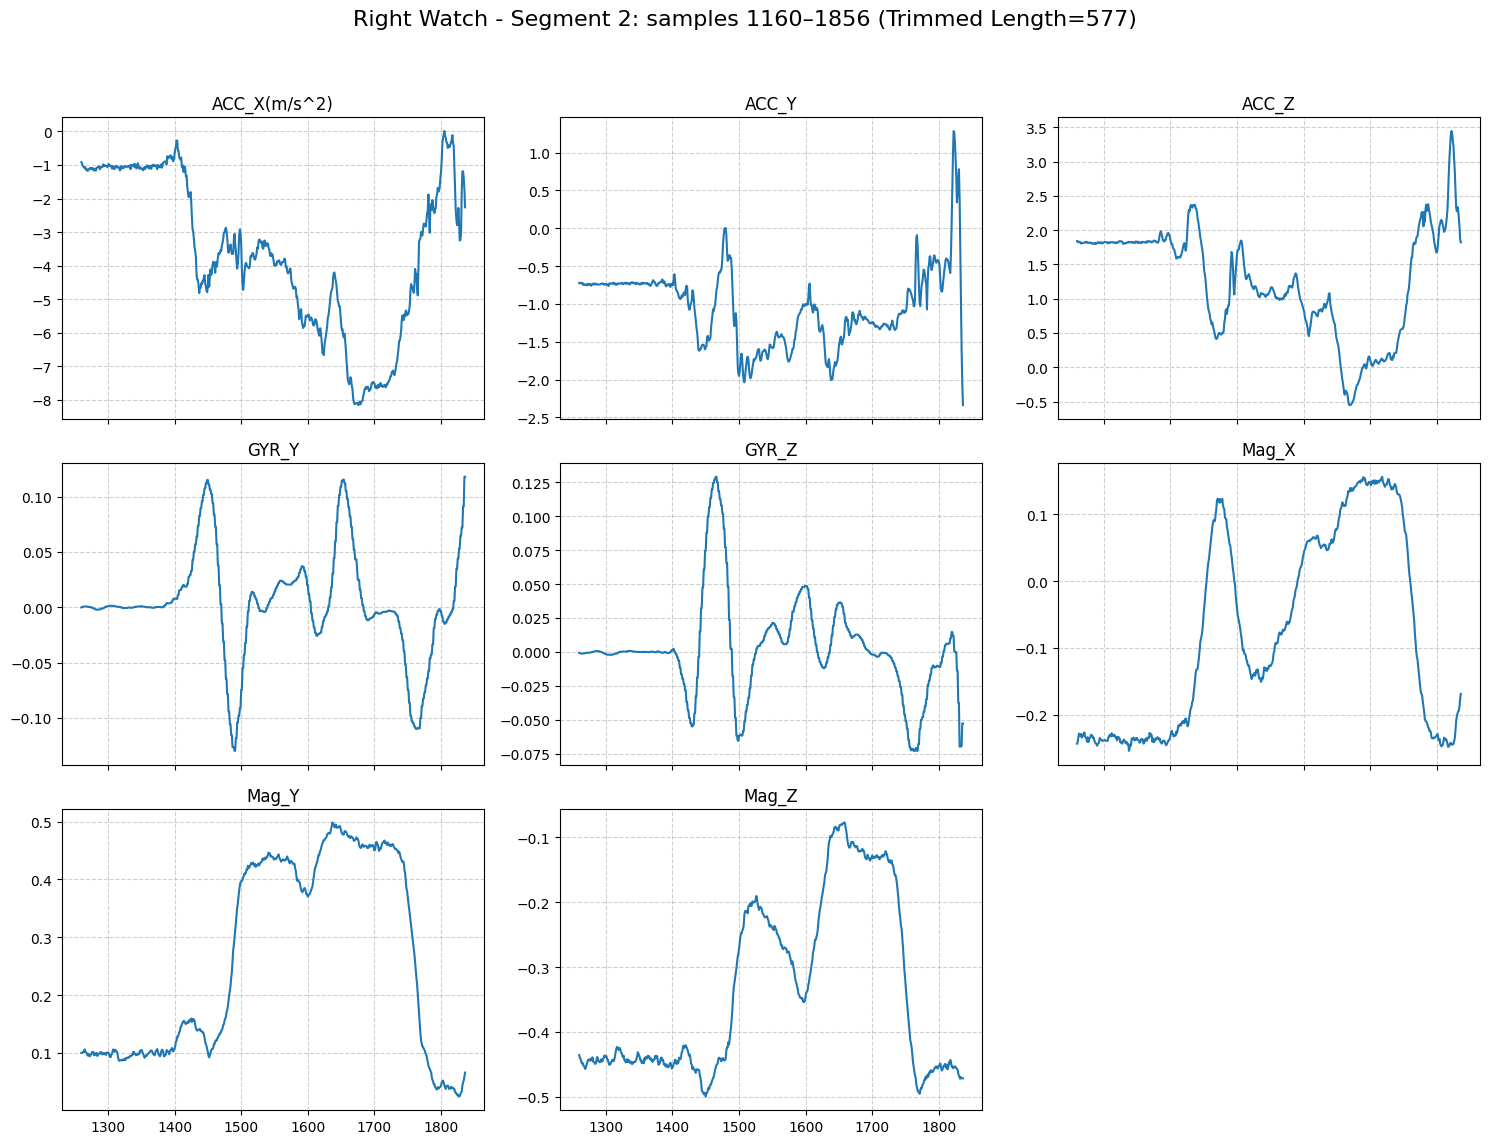

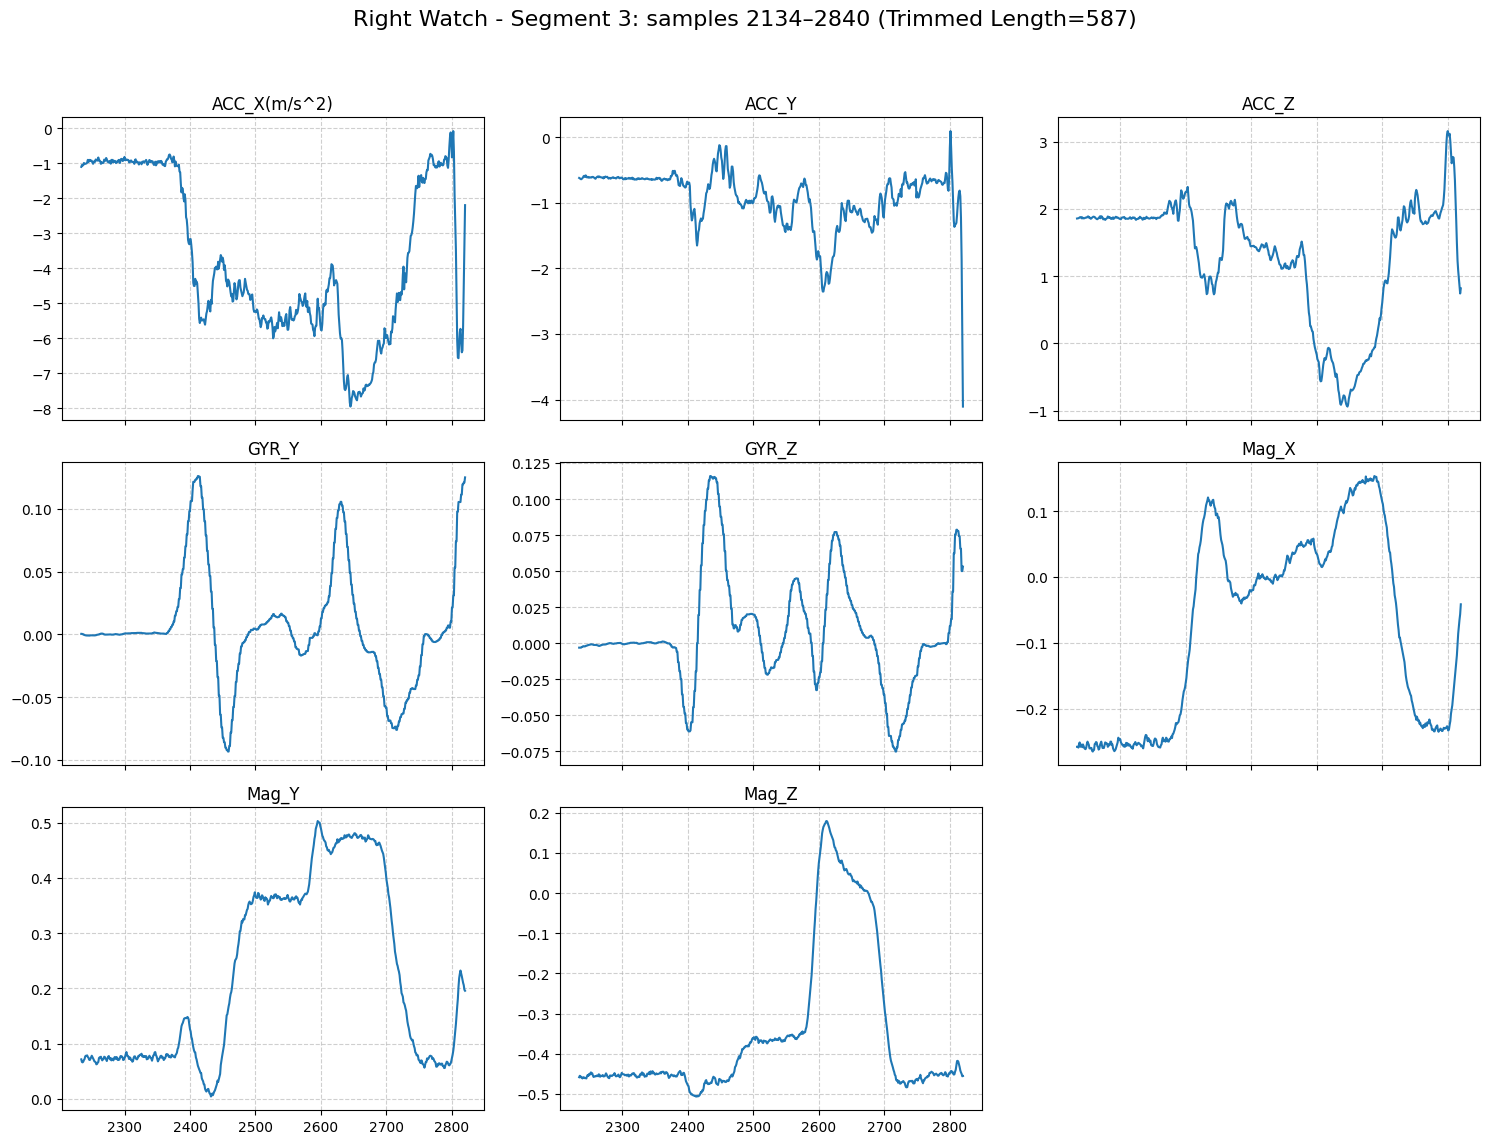

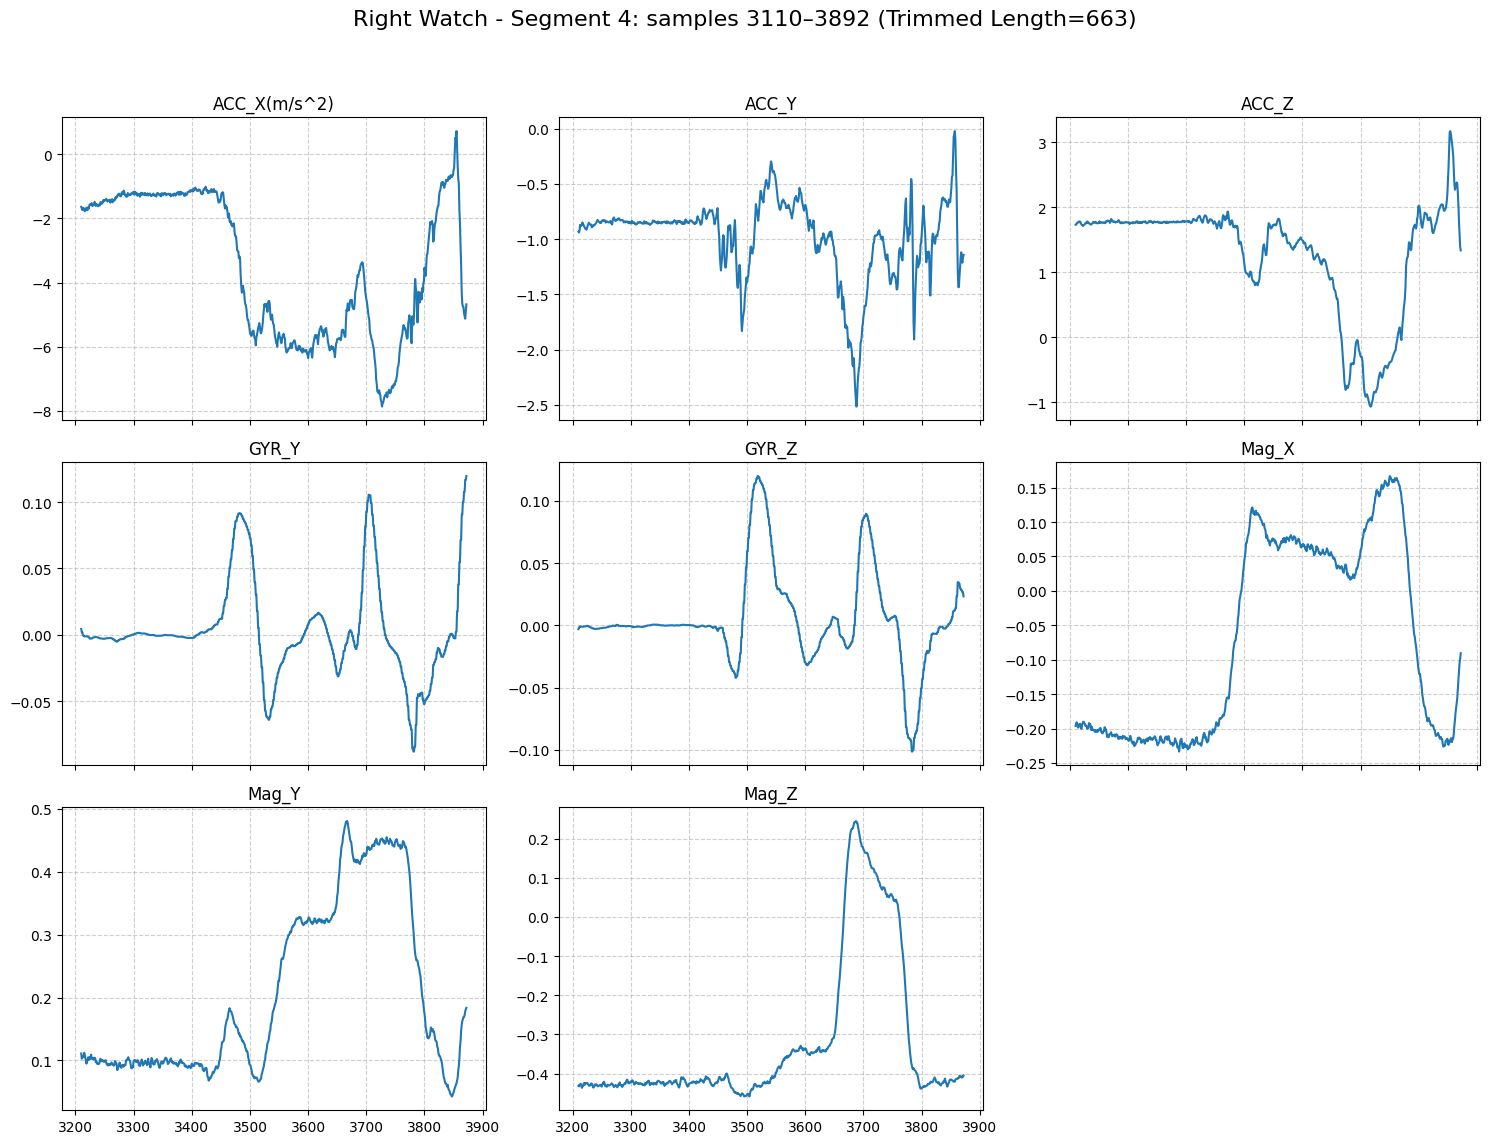

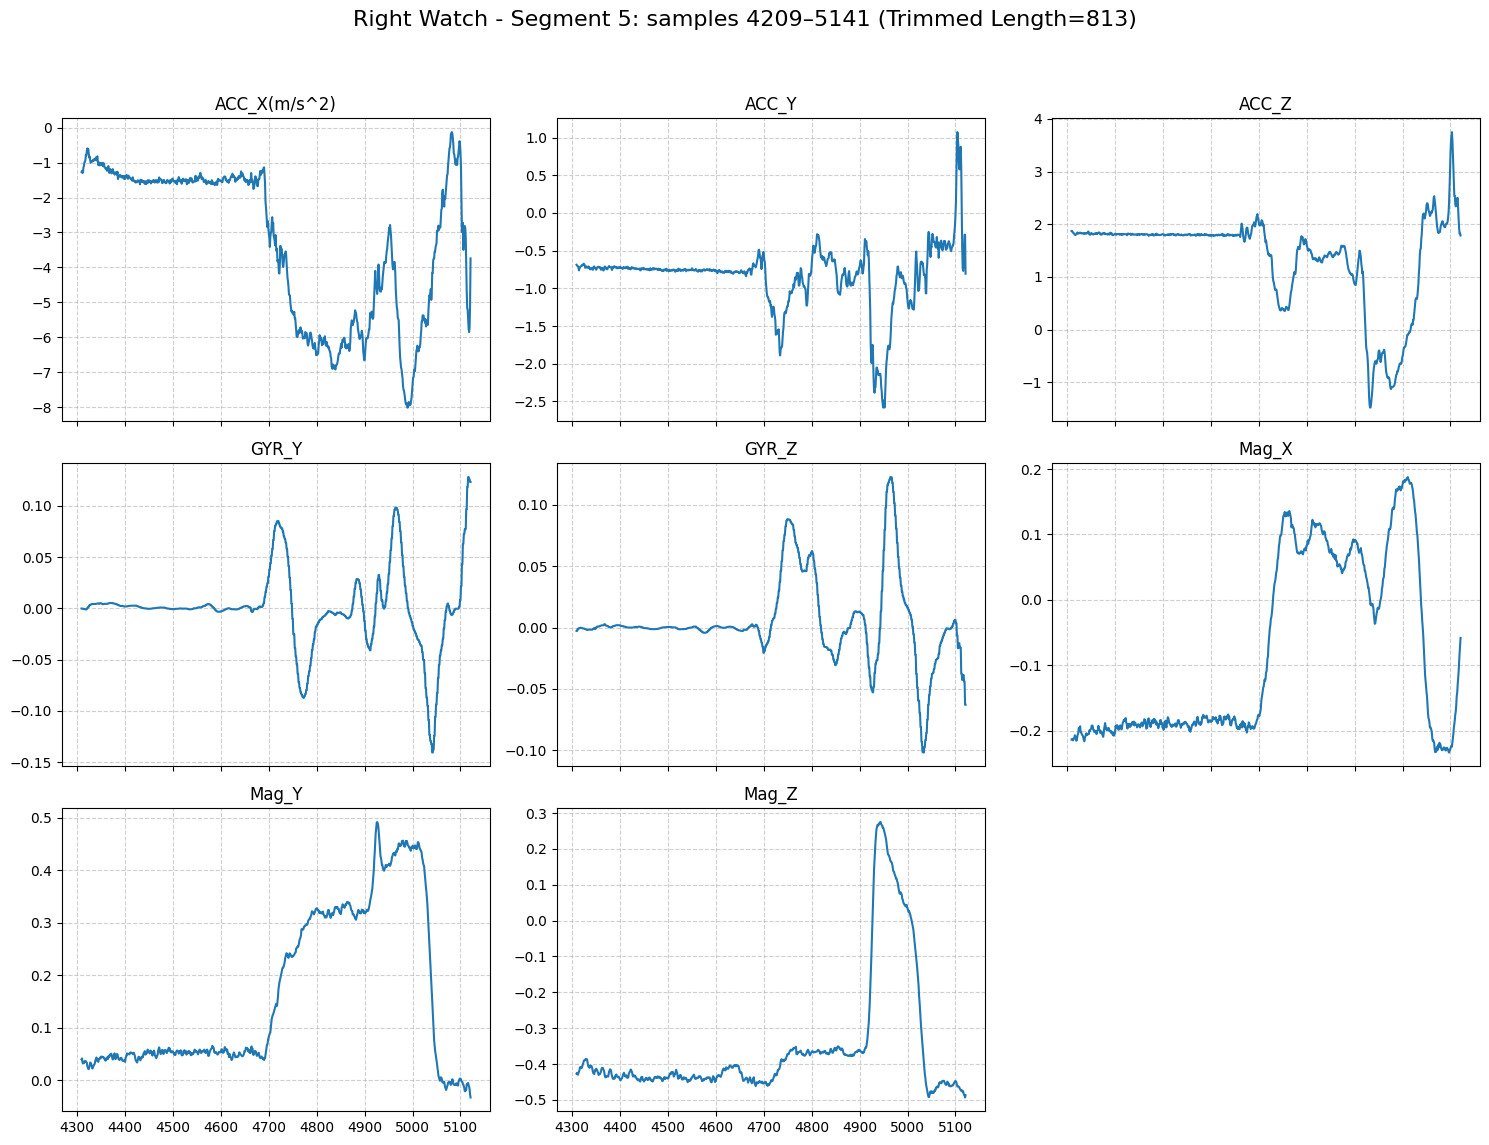

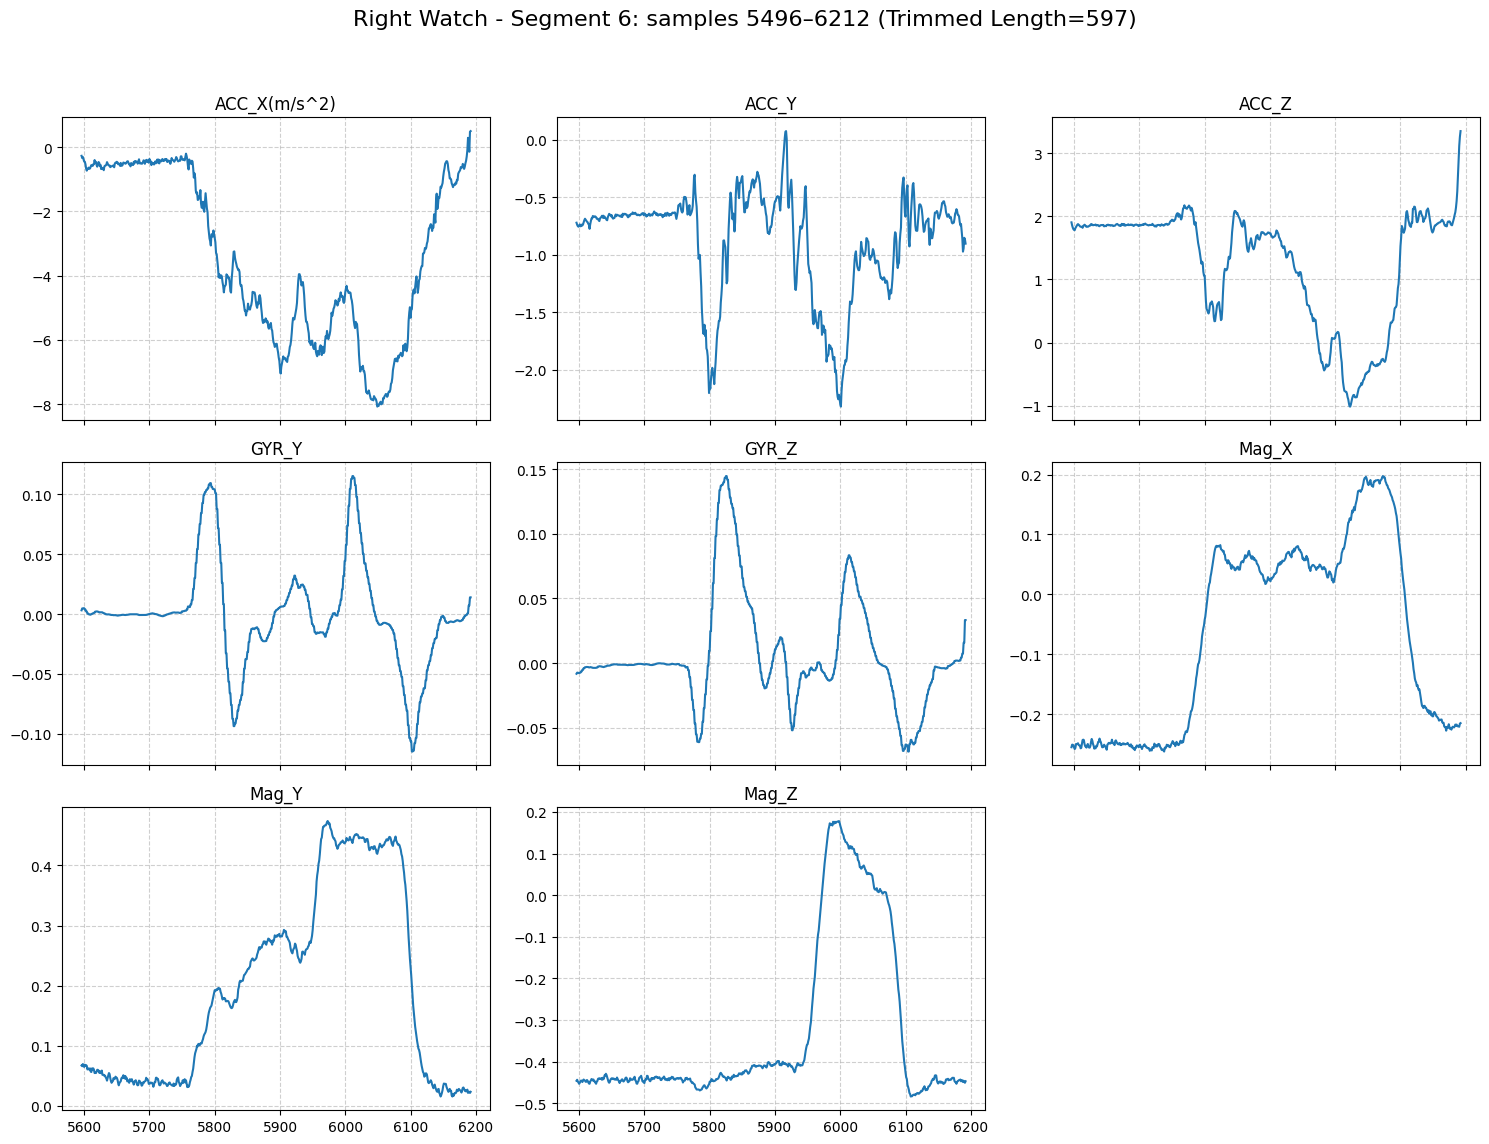

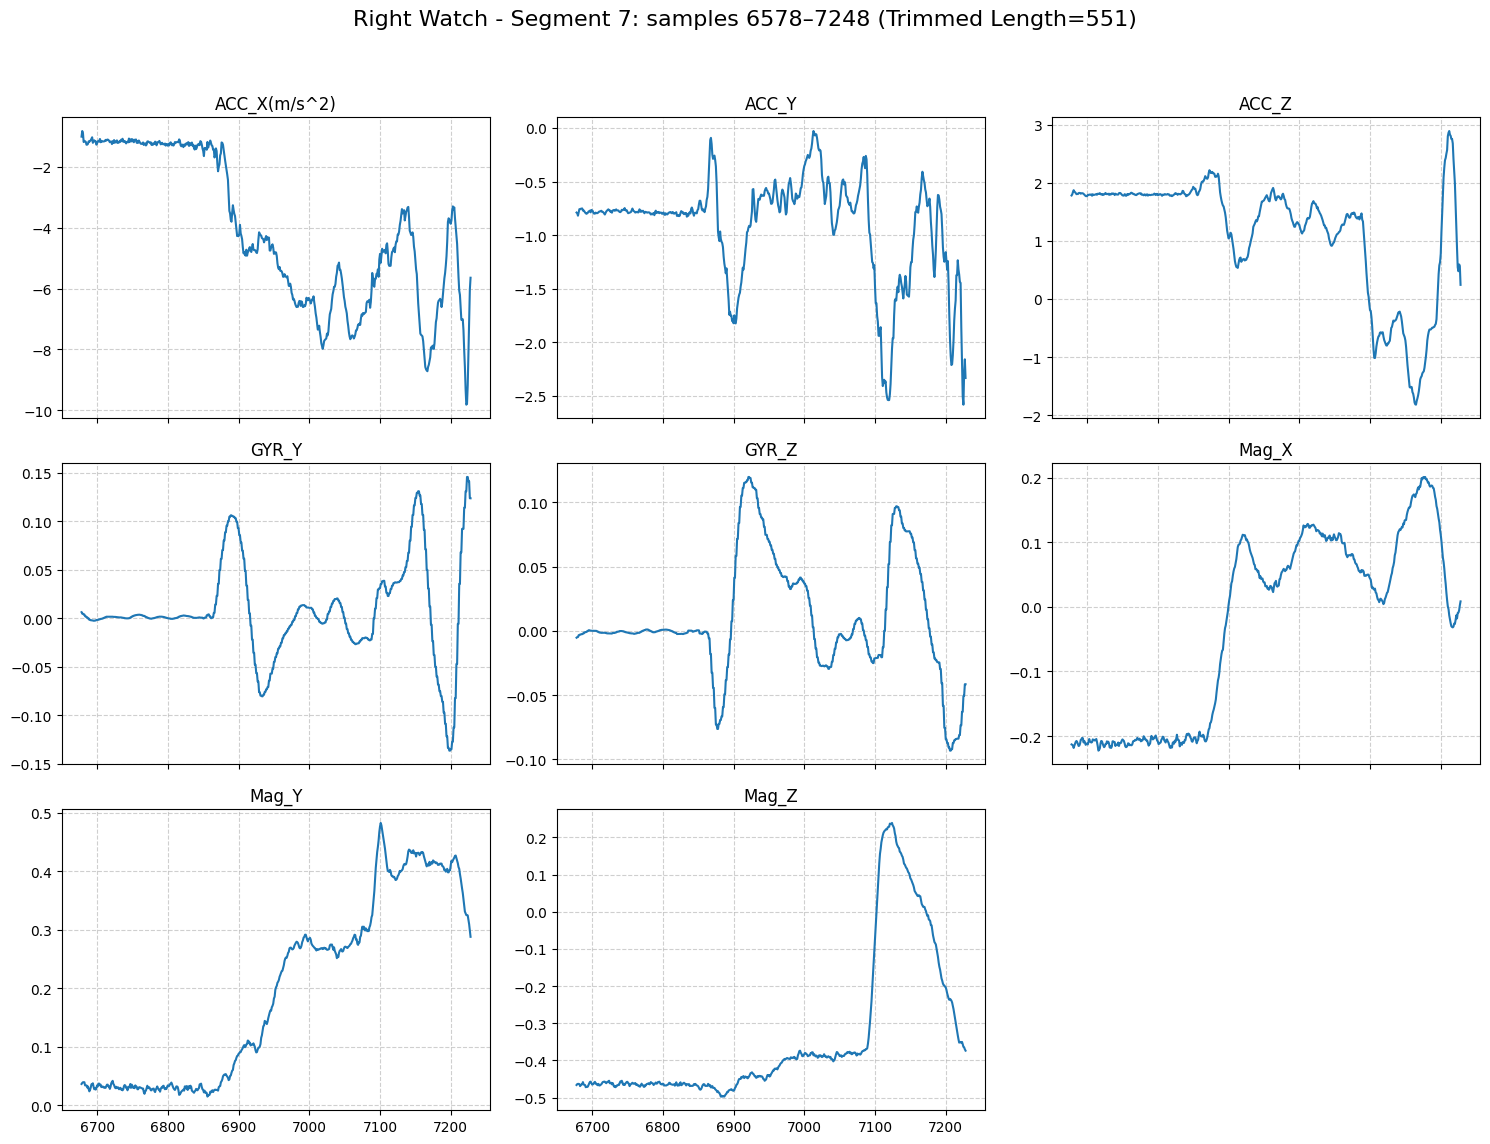


===== Processing: Left Watch =====
Input data shape: (8559, 24)
Using parameters: {'WINDOW': 2, 'STD_QUANTILE': 0.95, 'MIN_DURATION': 10, 'VAL_THRESH': 20, 'LENGTH_THRESH': 300, 'TRIM1': 100, 'TRIM2': 20, 'SAX_PARAMS': {'WORD_LENGTH': 16, 'ALPHABET_SIZE': 12, 'SIMILARITY_THRESHOLD': 3, 'SAX_FILTER_METRIC': 'changes', 'SAX_FILTER_THRESHOLD_GT': 7, 'SAX_FILTER_THRESHOLD_LT': None}}
Using Acc channels: ['ACC_X(m/s^2)', 'ACC_Y', 'ACC_Z']
Using other IMU channels: ['GYR_Y', 'GYR_Z', 'Mag_X', 'Mag_Y', 'Mag_Z']
Extracting segments based on Acc channels for Left Watch...
Extracted 7 segments: [(np.int64(0), np.int64(921)), (np.int64(1377), np.int64(2039)), (np.int64(2325), np.int64(3033)), (np.int64(3298), np.int64(4094)), (np.int64(4412), np.int64(5341)), (np.int64(5681), np.int64(6397)), (np.int64(6766), np.int64(7438))]
Generated 7 unique SAX pattern groups (before filtering).

--- SAX Pattern Metrics & Filtering (Left Watch) ---
  Group 1 (SAX: lllieedddddddddc): Changes=4, Range=9, Volat

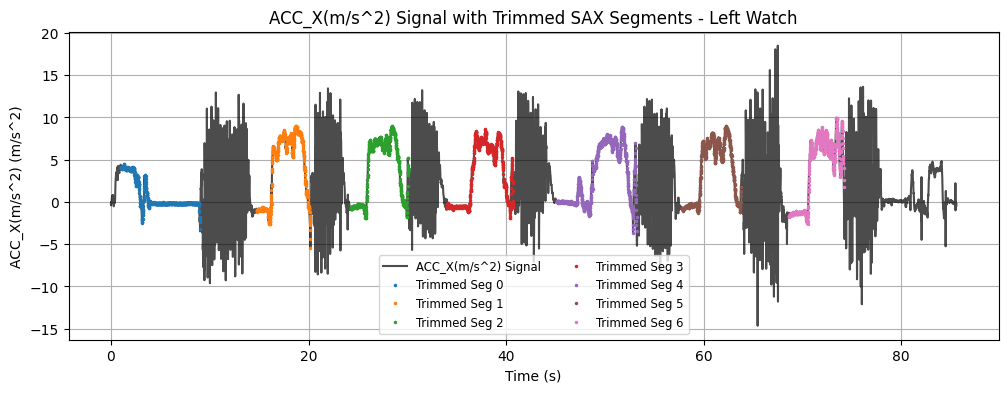

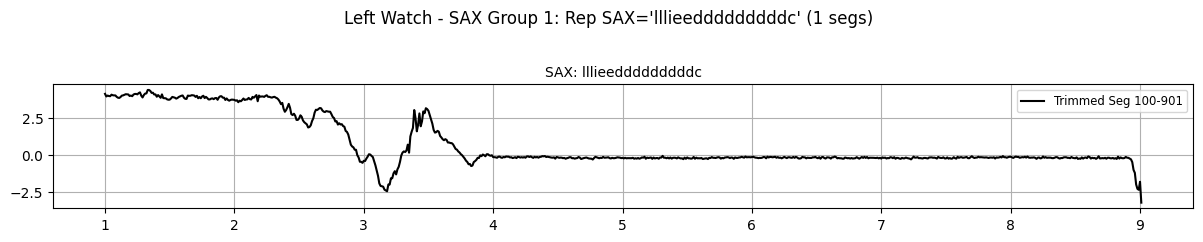

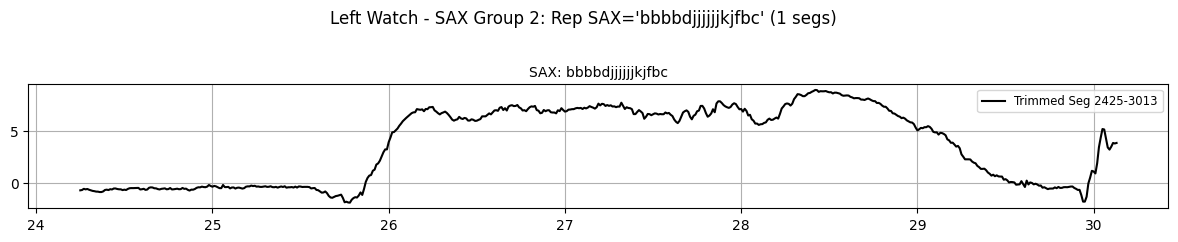

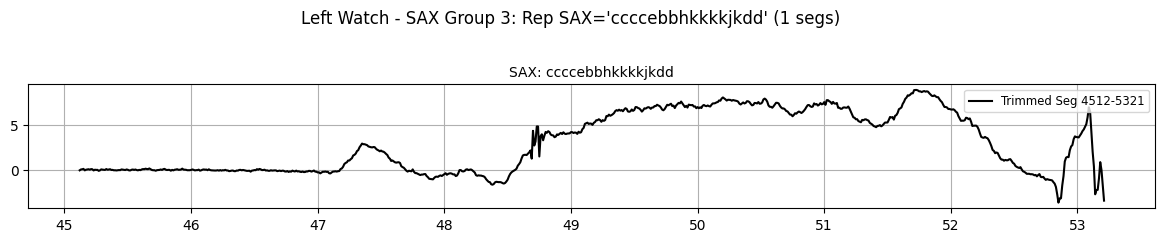

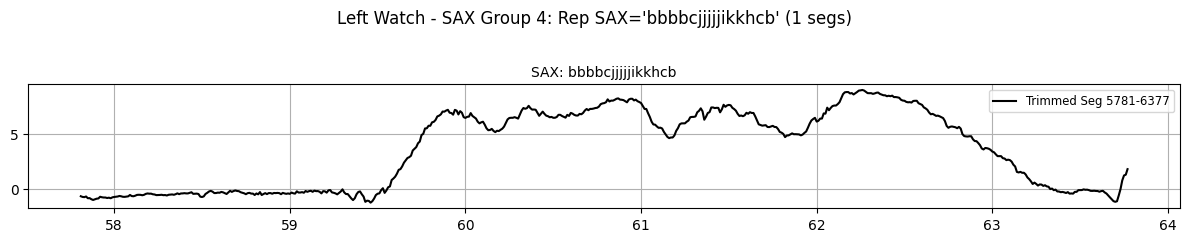

Generating IMU channel plots for Left Watch...


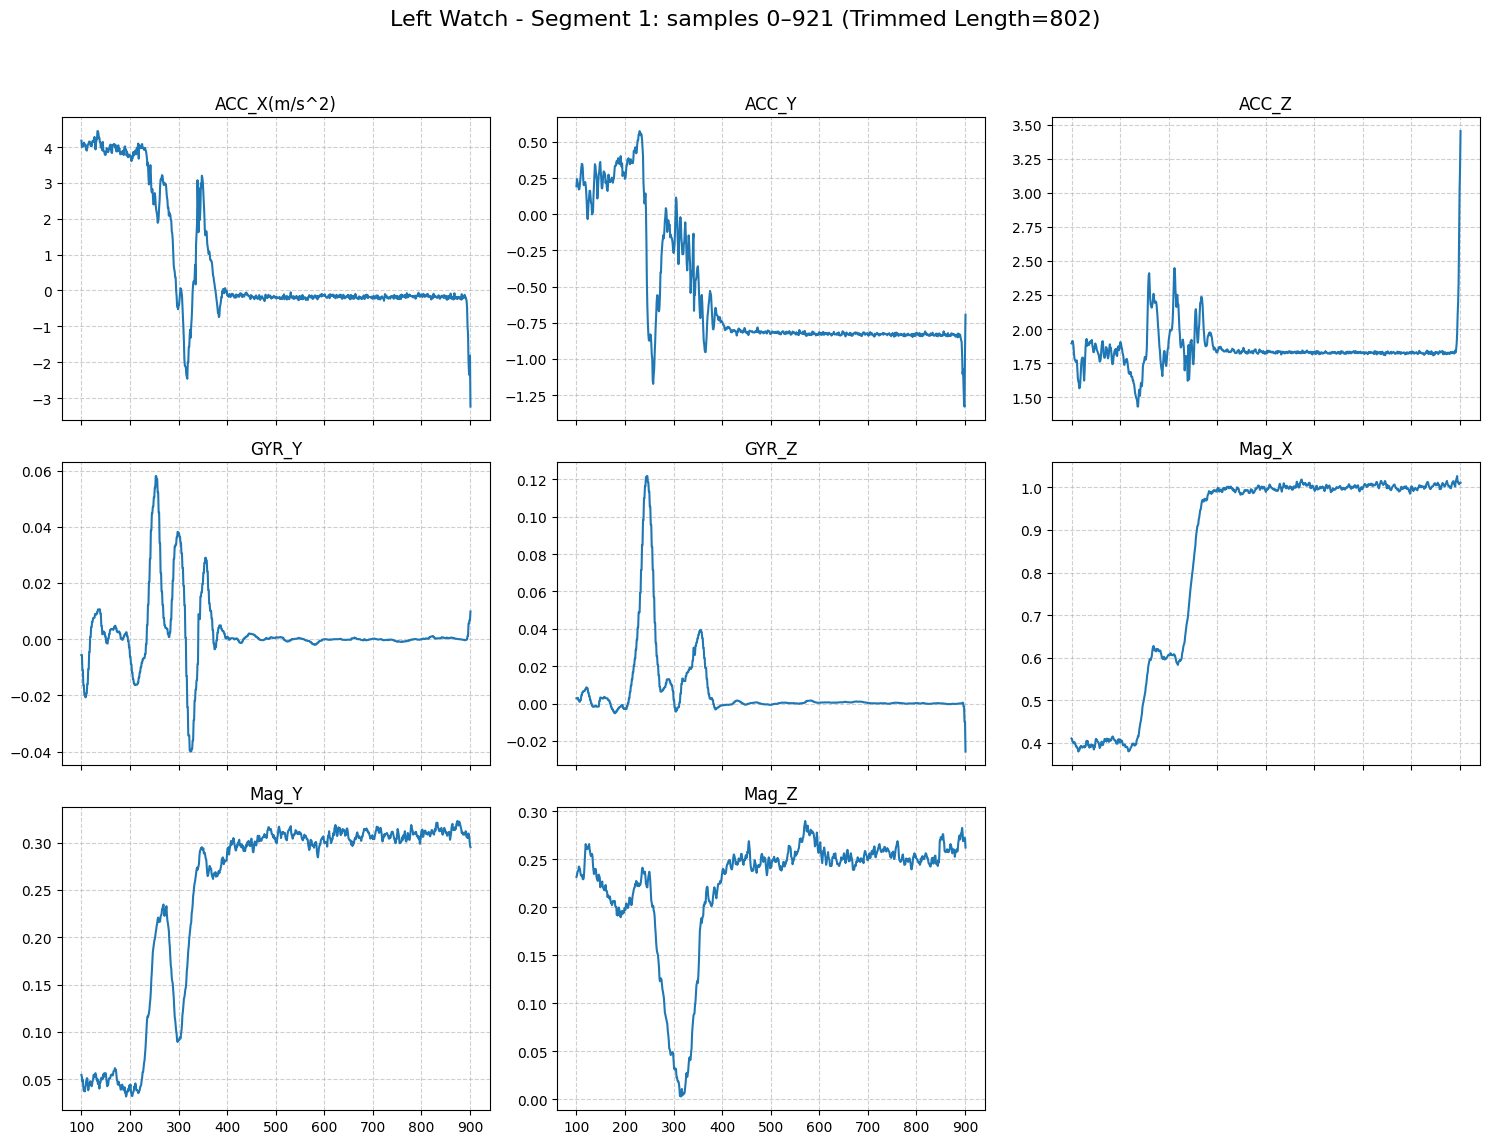

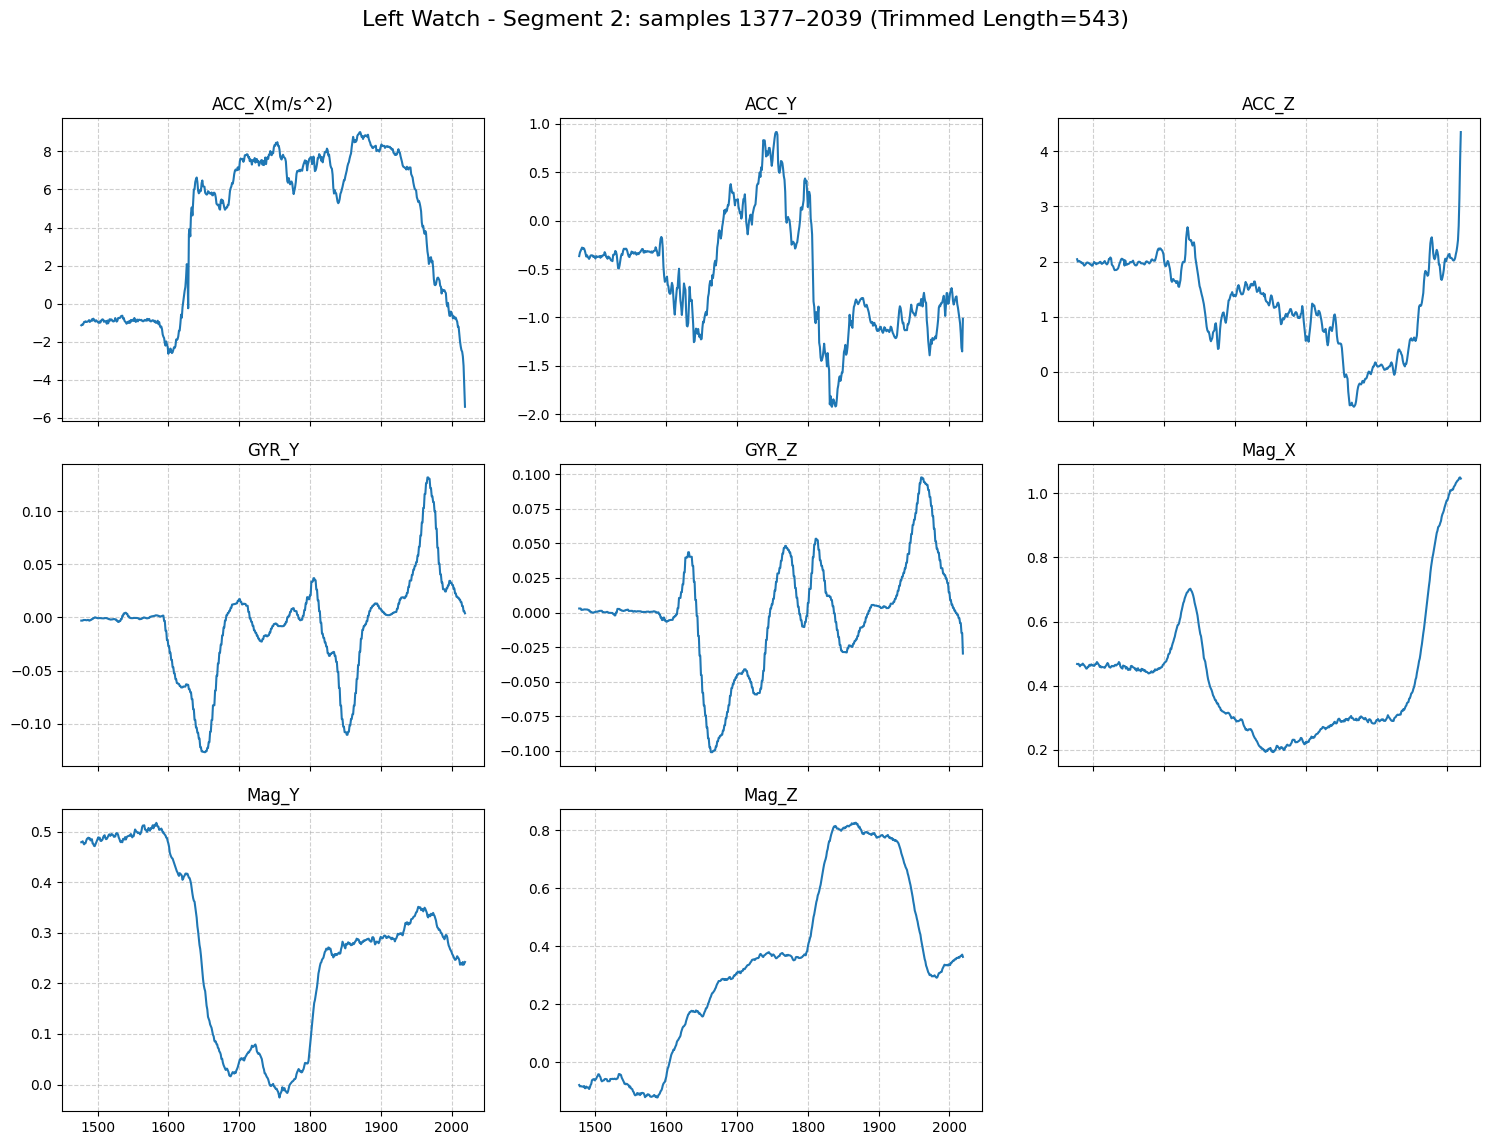

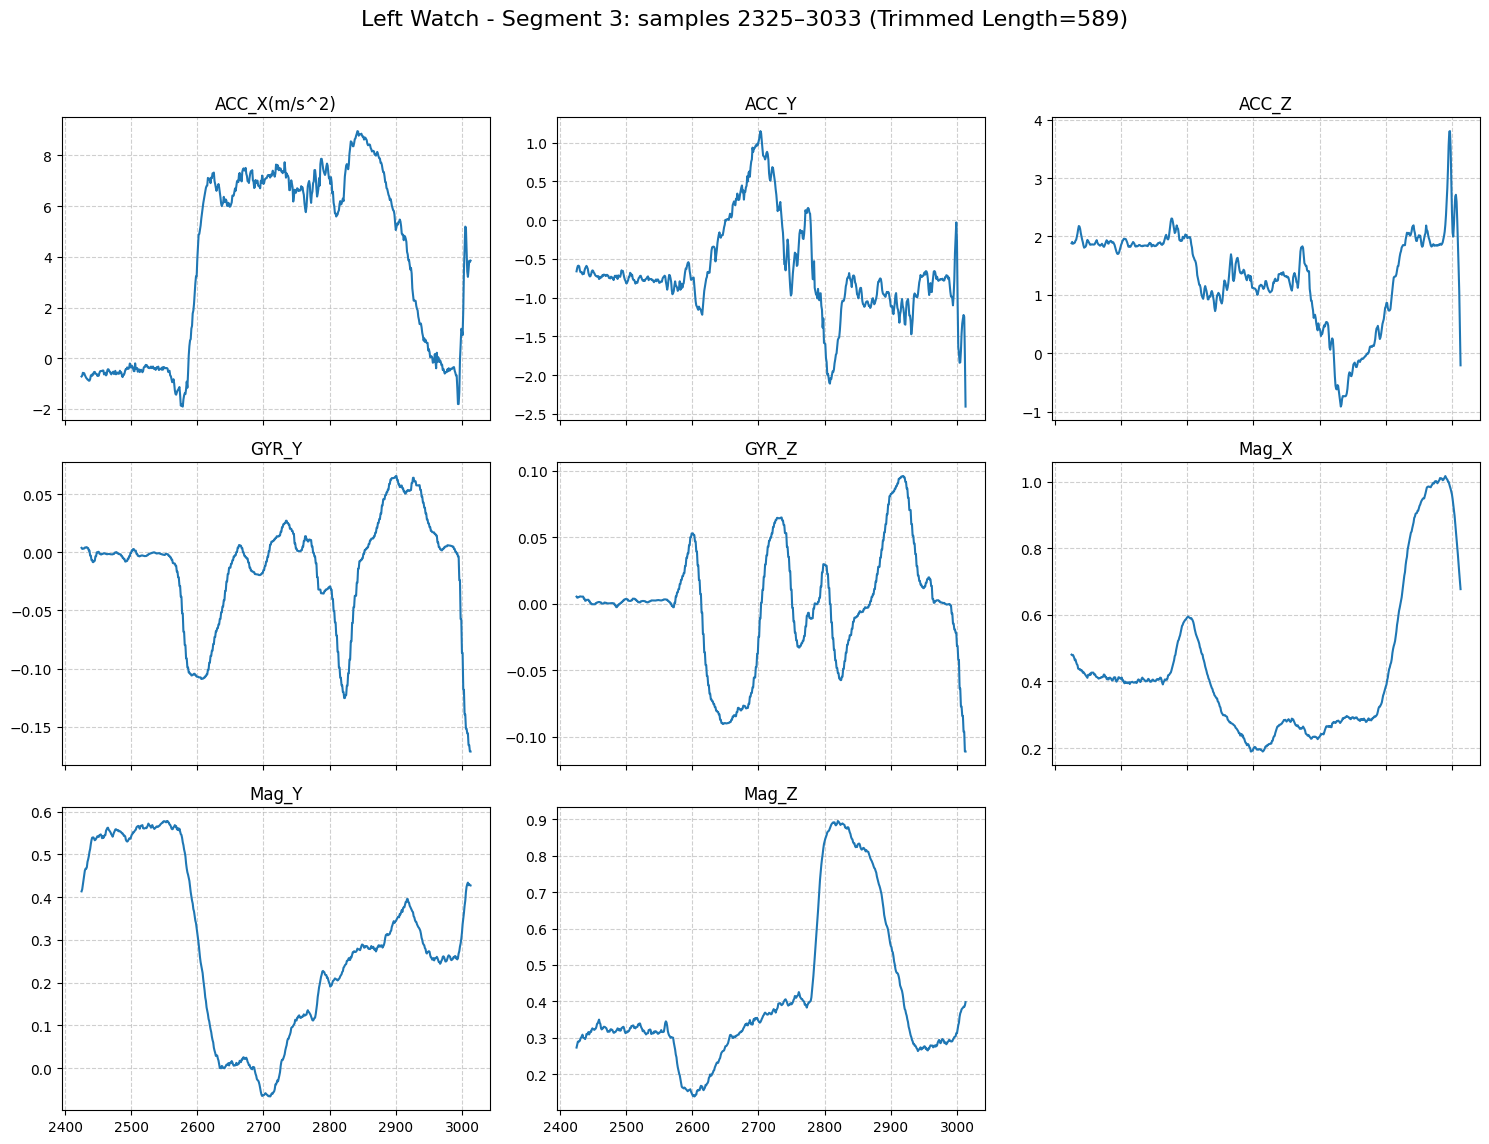

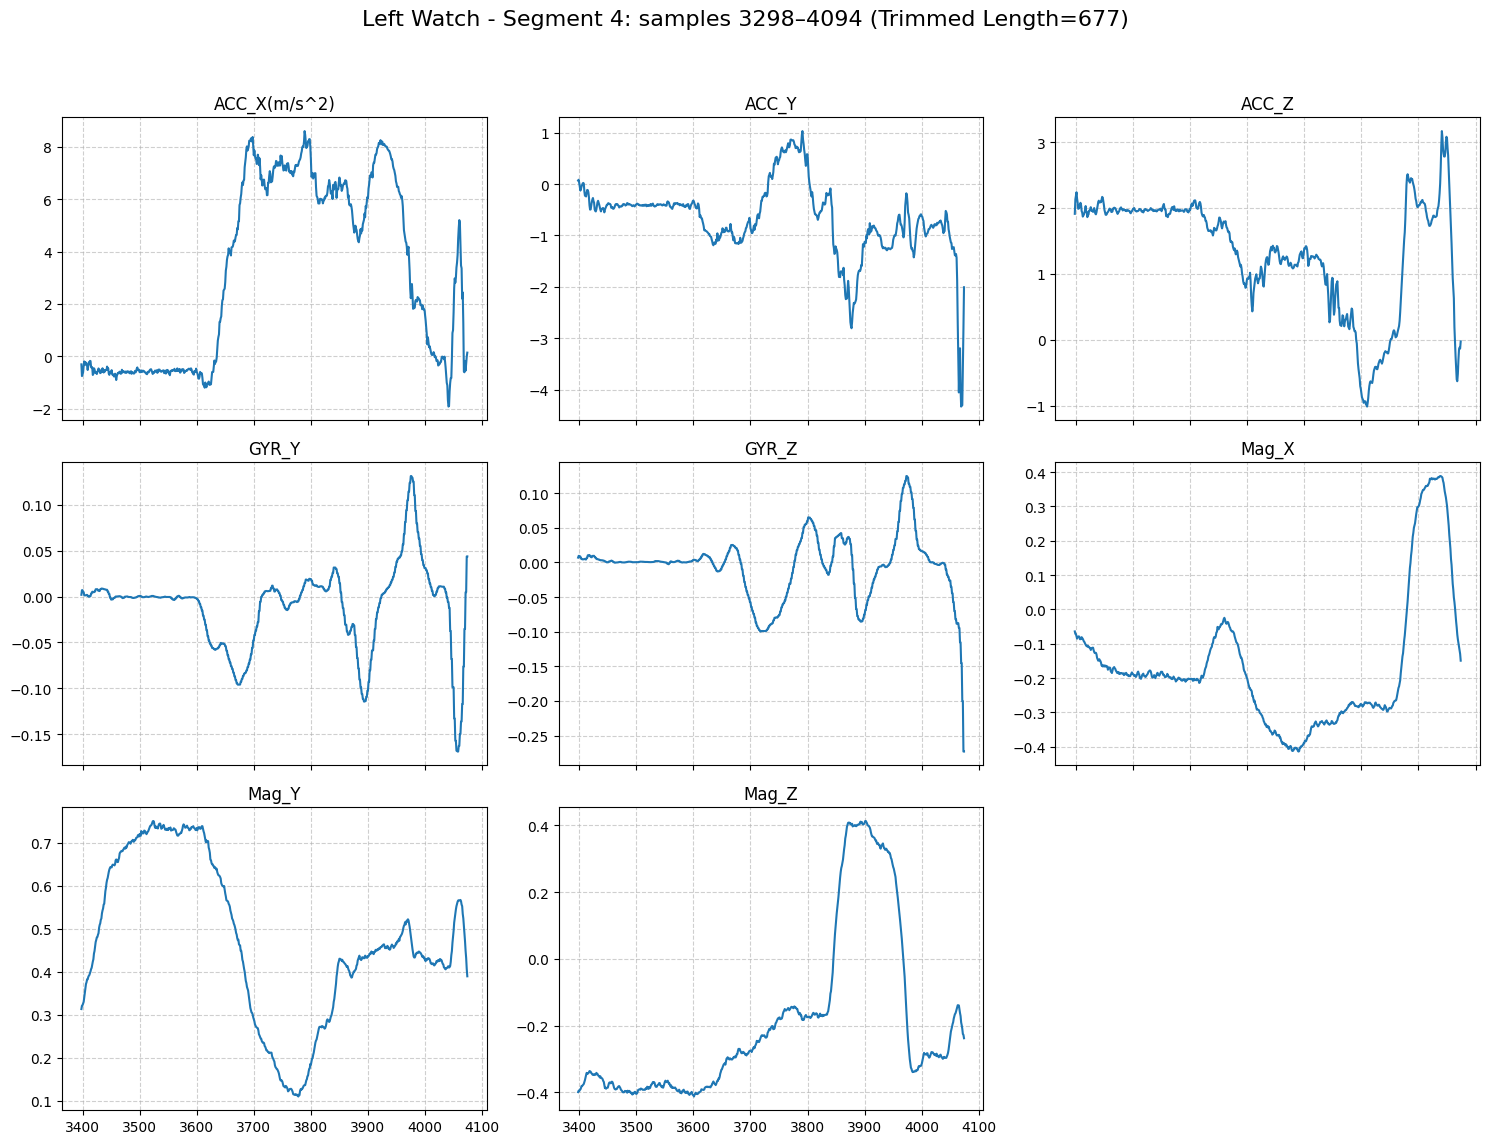

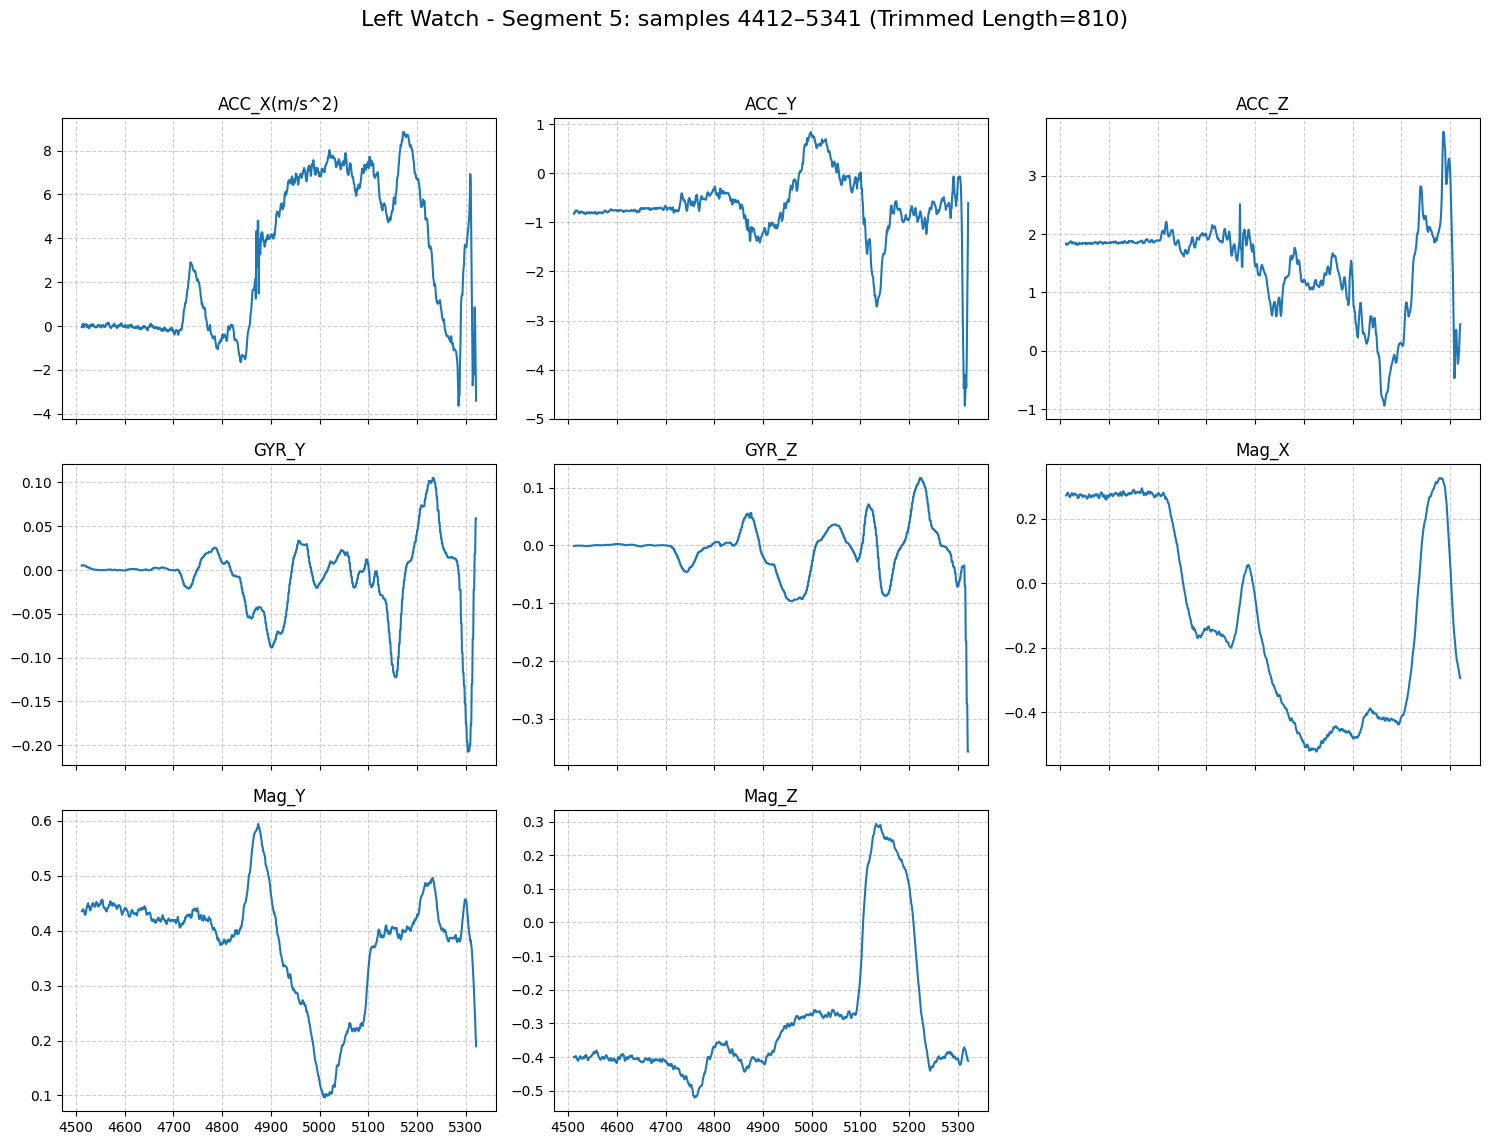

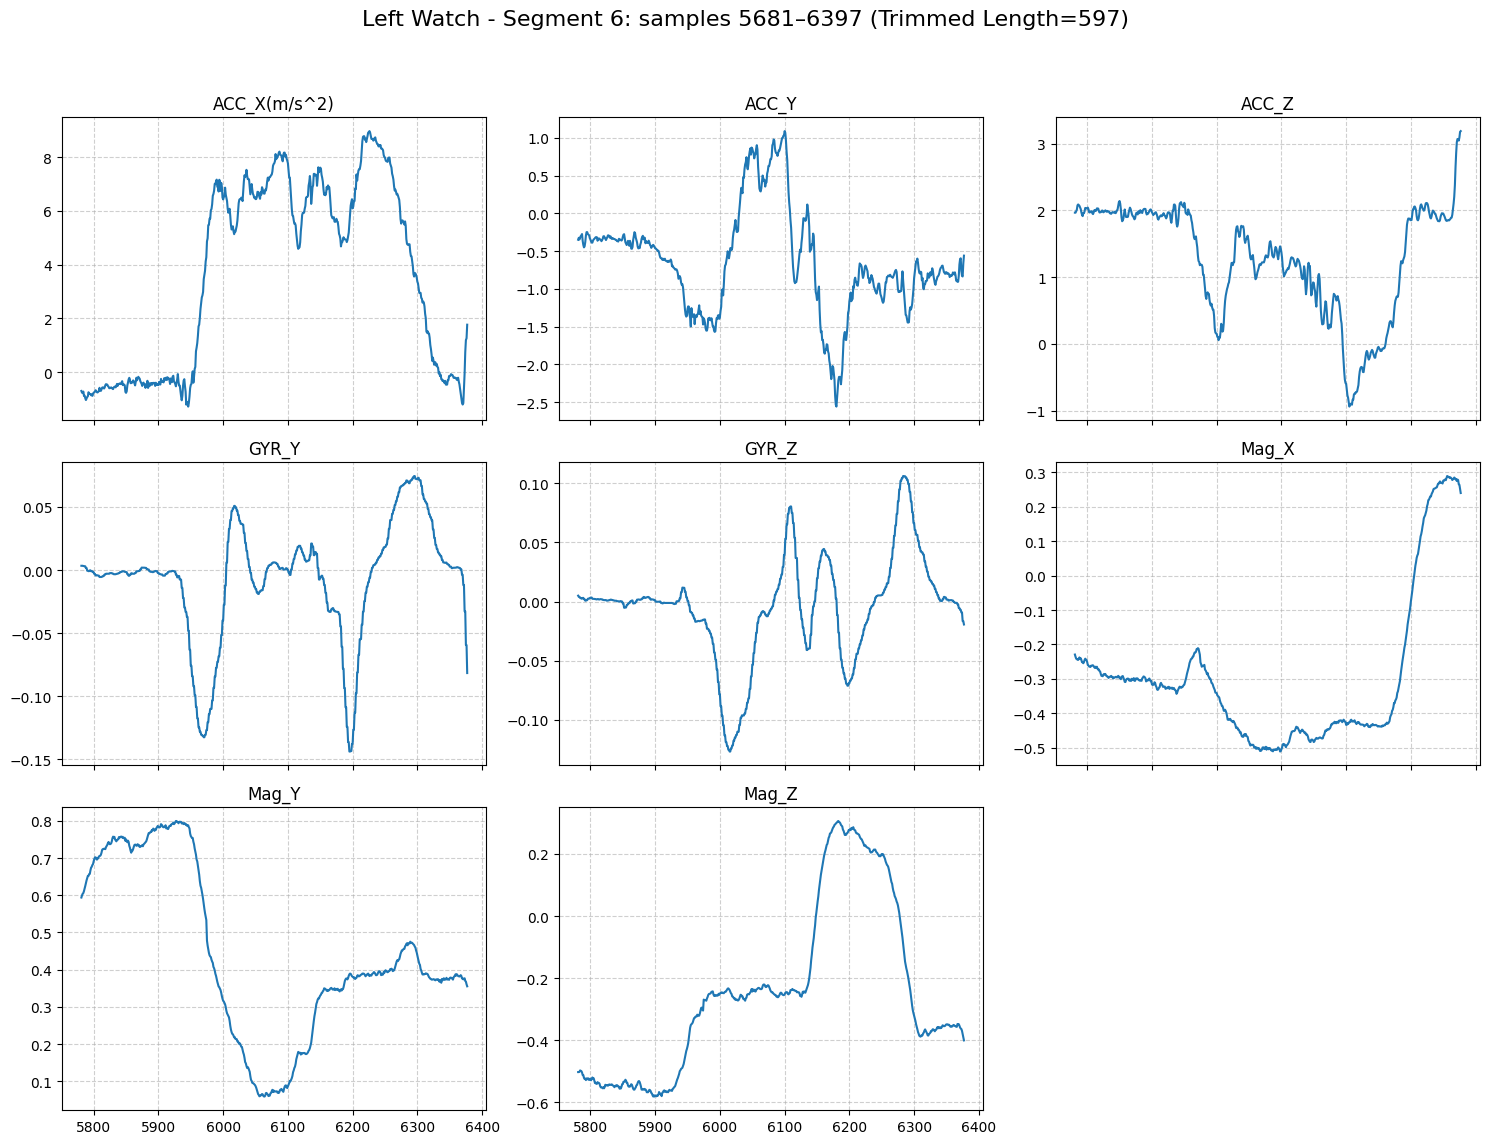

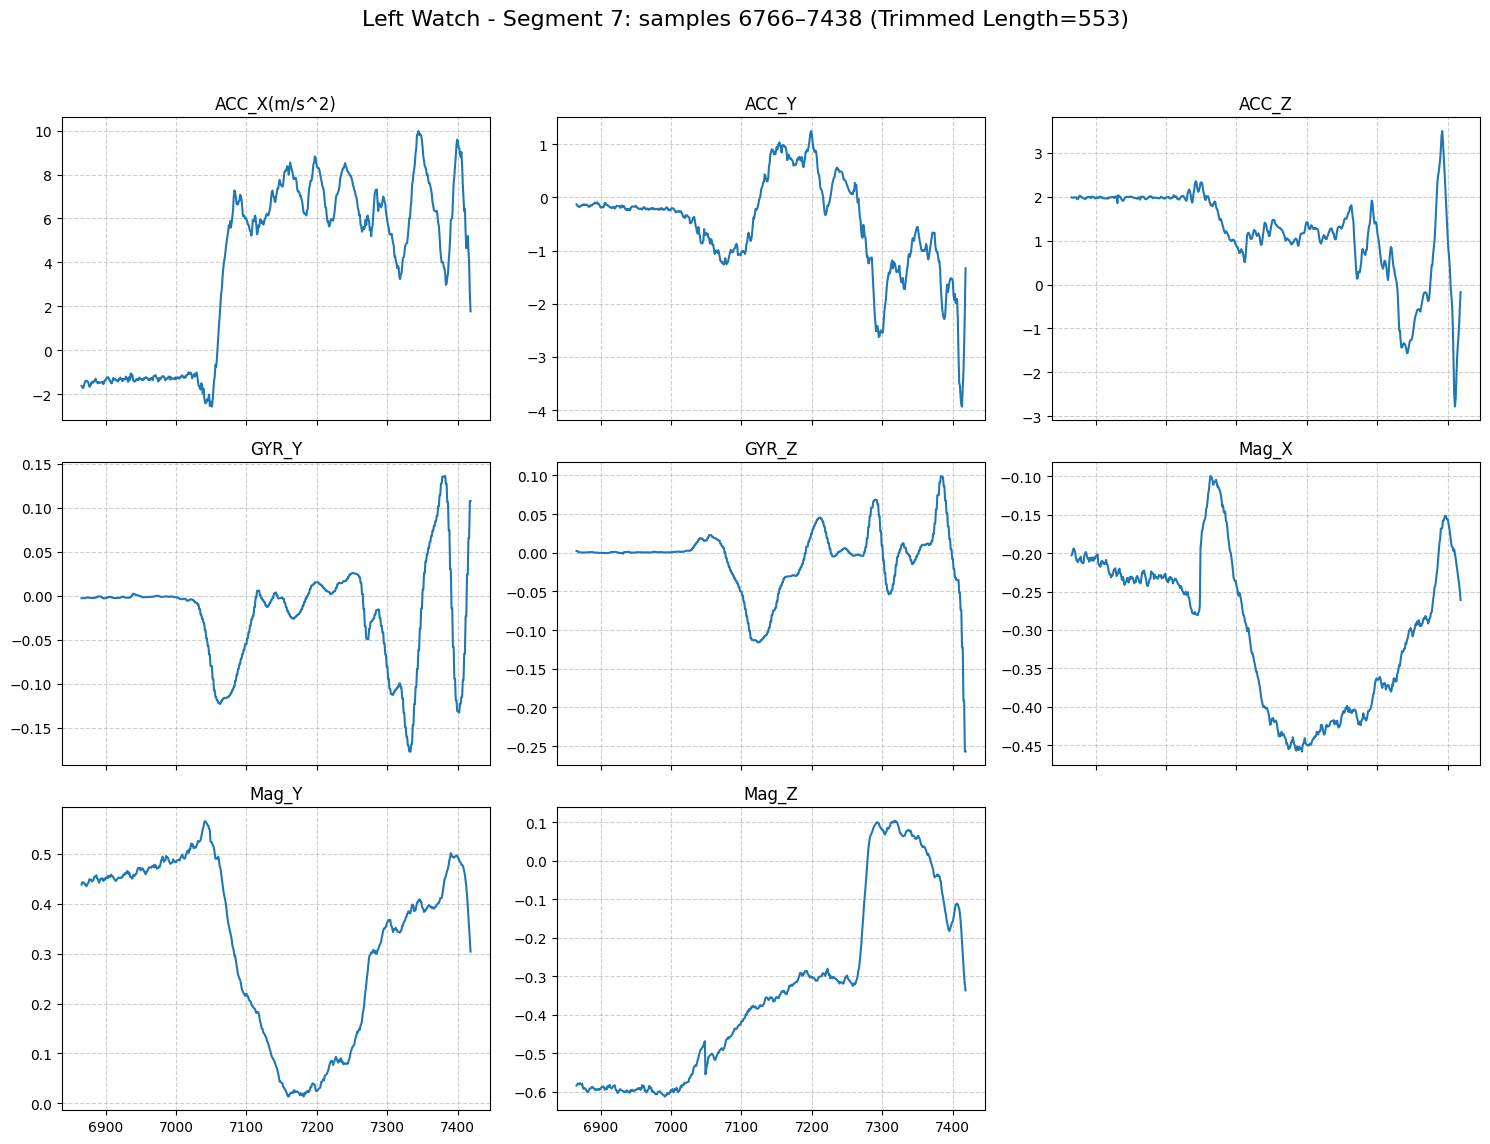


All processing finished.


In [3]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.stats import norm

# --- SAX Algorithm Functions ---
def z_normalize(series):
    if len(series) == 0: return np.array([])
    mean = np.mean(series); std = np.std(series)
    if std == 0: return np.zeros_like(series)
    return (series - mean) / std

def paa(series, num_segments):
    if num_segments <= 0: raise ValueError("num_segments must be positive")
    n = len(series)
    if n == 0: return np.full(num_segments, np.nan)
    segments = np.array_split(series, num_segments)
    return np.array([np.mean(seg) for seg in segments])

def get_breakpoints(alphabet_size):
    if not isinstance(alphabet_size, int) or alphabet_size < 1:
        raise ValueError("alphabet_size must be a positive integer")
    if alphabet_size <= 1: return np.array([])
    return norm.ppf(np.linspace(1/alphabet_size, 1 - 1/alphabet_size, alphabet_size - 1))

def series_to_sax(series, word_length, alphabet_size):
    if word_length <= 0 or alphabet_size <= 0:
        raise ValueError("word_length and alphabet_size must be positive")
    if alphabet_size > 26:
        raise ValueError("alphabet_size must not exceed 26 for lowercase letters")
    if not isinstance(series, np.ndarray): series_np = np.array(series, dtype=np.float64)
    else: series_np = series.astype(np.float64)
    if len(series_np) == 0: return "!" * word_length
    normalized_series = z_normalize(series_np)
    paa_values = paa(normalized_series, word_length)
    if np.isnan(paa_values).any():
        if np.all(np.isnan(paa_values)): return "?" * word_length
        paa_values = np.nan_to_num(paa_values, nan=0.0)
    breakpoints = get_breakpoints(alphabet_size); sax_list = []
    alphabet = [chr(ord('a') + i) for i in range(alphabet_size)]
    for val in paa_values:
        sax_list.append(alphabet[np.searchsorted(breakpoints, val)])
    return "".join(sax_list)

def levenshtein_distance(s1, s2):
    if len(s1) < len(s2): return levenshtein_distance(s2, s1)
    if len(s2) == 0: return len(s1)
    prev_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        curr_row = [i + 1]
        for j, c2 in enumerate(s2):
            subs = prev_row[j] + (c1 != c2)
            curr_row.append(min(prev_row[j+1]+1, curr_row[j]+1, subs))
        prev_row = curr_row
    return prev_row[-1]

def count_symbol_changes(sax_str):
    if not sax_str or len(sax_str) < 2: return 0
    changes = 0
    for i in range(len(sax_str) - 1):
        if sax_str[i] != sax_str[i+1]:
            changes += 1
    return changes

def get_sax_symbol_range(sax_str):
    if not sax_str: return 0
    valid_chars = [s for s in sax_str if s.islower()]
    if not valid_chars: return 0
    ordinal_values = [ord(s) - ord('a') for s in valid_chars]
    return max(ordinal_values) - min(ordinal_values)

def get_sax_value_volatility(sax_str):
    if not sax_str or len(sax_str) < 2: return 0
    valid_chars = [s for s in sax_str if s.islower()]
    if len(valid_chars) < 2: return 0
    ordinal_values = [ord(s) - ord('a') for s in valid_chars]
    volatility = sum(abs(ordinal_values[i+1] - ordinal_values[i]) for i in range(len(ordinal_values)-1))
    return volatility

# --- File Paths ---
drive_base = '/content/drive/MyDrive/watch_ring/250429/04April_2011_Monday_heute-956'
right_watch_path = os.path.join(drive_base, 'right_watch/fusion_20240617-150340.csv')
left_watch_path = os.path.join(drive_base, 'left_watch/fusion_20240416-120255.csv')

# --- Reusable Functions ---
def extract_acc_segments(df, channels, window, std_q, min_dur, val_thresh, length_thresh):
    if not all(ch in df.columns for ch in channels):
        print(f"  Error: Not all required Acc channels ({channels}) found in DataFrame columns: {df.columns.tolist()}")
        return []
    try:
        rs = df[channels].rolling(window=window, center=True).std().ffill().bfill().fillna(0)
        th = rs.quantile(std_q)
        calm_conditions = []
        for ch in channels:
            if pd.isna(th[ch]):
                print(f"    Warning: Could not compute threshold for channel '{ch}'. Skipping channel for calm mask.")
                calm_conditions.append(pd.Series([False] * len(df), index=df.index))
            else:
                calm_conditions.append(rs[ch] < th[ch])
        if not calm_conditions:
            print("    Error: Could not compute thresholds for any Acc channel.")
            return []
        calm_mask = np.logical_and.reduce(calm_conditions)
        calm_mask = pd.Series(calm_mask, index=df.index)
        diff = calm_mask.astype(int).diff().fillna(0)
        starts = np.where(diff == 1)[0]
        ends = np.where(diff == -1)[0]
        if len(calm_mask) > 0:
            if calm_mask.iloc[0]:
                starts = np.insert(starts, 0, 0)
            if len(ends) < len(starts) and calm_mask.iloc[-1]:
                ends = np.append(ends, len(calm_mask) - 1)
        min_len = min(len(starts), len(ends))
        starts = starts[:min_len]
        ends = ends[:min_len]
        segs = []
        for s, e in zip(starts, ends):
            if s >= e: continue
            length = e - s + 1
            if length < min_dur: continue
            segment_data = df[channels].iloc[s : e + 1]
            if segment_data.fillna(0).abs().max().max() <= val_thresh: continue
            if length <= length_thresh: continue
            segs.append((s, e))
        return segs
    except Exception as e:
        print(f"  Error during segment extraction: {e}")
        return []

def tanh1_np(x_np):
    if not isinstance(x_np, np.ndarray): x_np = np.array(x_np, dtype=np.float64)
    x_scaled = x_np * 1e-5
    v_clip = np.clip(x_scaled, -20.0, 20.0)
    out = np.tanh(v_clip)
    if len(out) > 1:
        out[1:] *= 2
    return out * 10000

def tanh2_np(x_np):
    if not isinstance(x_np, np.ndarray): x_np = np.array(x_np, dtype=np.float64)
    x_scaled = x_np * 1e-5
    v_clip = np.clip(x_scaled, -20.0, 20.0)
    out = np.tanh(v_clip)
    return out * 100

def tanh3_np(x_np):
    if not isinstance(x_np, np.ndarray): x_np = np.array(x_np, dtype=np.float64)
    x_scaled = x_np * 1e-5
    v_clip = np.clip(x_scaled, -20.0, 20.0)
    out = np.tanh(v_clip)
    return out * 1000

# --- Main Processing Function with SAX ---
def process_and_plot(df, watch_label, params):
    print(f"\n===== Processing: {watch_label} =====")
    if df is None or df.empty:
        print("Input DataFrame is empty or None. Skipping.")
        return

    print(f"Input data shape: {df.shape}")
    print(f"Using parameters: {params}")

    # Channel definitions
    acc_channels = ['ACC_X(m/s^2)', 'ACC_Y', 'ACC_Z']
    gyr_channels = ['GYR_Y', 'GYR_Z']
    mag_channels = ['Mag_X', 'Mag_Y', 'Mag_Z']
    imu_other_channels = gyr_channels + mag_channels
    all_imu_channels = acc_channels + imu_other_channels
    print(f"Using Acc channels: {acc_channels}")
    print(f"Using other IMU channels: {imu_other_channels}")

    # Extract acceleration-based segments
    print(f"Extracting segments based on Acc channels for {watch_label}...")
    acc_segs = extract_acc_segments(
        df, acc_channels,
        window=params['WINDOW'],
        std_q=params['STD_QUANTILE'],
        min_dur=params['MIN_DURATION'],
        val_thresh=params['VAL_THRESH'],
        length_thresh=params['LENGTH_THRESH']
    )
    print(f"Extracted {len(acc_segs)} segments: {acc_segs}")

    if not acc_segs:
        print(f"No valid segments found for {watch_label}. Skipping SAX and plots.")
        return

    # SAX Processing on trimmed ACC_X(m/s^2)
    sax_channel = 'ACC_X(m/s^2)'
    if sax_channel not in df.columns:
        print(f"  Error: SAX channel '{sax_channel}' not found. Skipping SAX analysis.")
        return

    sax_params = params.get('SAX_PARAMS', {
        'WORD_LENGTH': 12,
        'ALPHABET_SIZE': 8,
        'SIMILARITY_THRESHOLD': 2,
        'SAX_FILTER_METRIC': 'volatility',
        'SAX_FILTER_THRESHOLD_GT': 15,
        'SAX_FILTER_THRESHOLD_LT': 7
    })

    # SAX Transformation with Trimming
    segment_sax_strings = []
    segments_for_sax = []
    trimmed_acc_segs = []
    for s, e in acc_segs:
        seg_data = df[sax_channel].iloc[s:e+1].to_numpy()
        seg_length = len(seg_data)
        trim_start = params['TRIM1']
        trim_end = seg_length - params['TRIM2']
        trimmed_length = seg_length - params['TRIM1'] - params['TRIM2']
        if trimmed_length < sax_params['WORD_LENGTH'] / 2:
            print(f"  Segment ({s}, {e}) too short after trimming (length={trimmed_length}, required={sax_params['WORD_LENGTH']/2}). Skipping SAX.")
            sax_str = "?" * sax_params['WORD_LENGTH']
        else:
            trimmed_seg_data = seg_data[trim_start:trim_end]
            sax_str = series_to_sax(trimmed_seg_data, sax_params['WORD_LENGTH'], sax_params['ALPHABET_SIZE'])
            segments_for_sax.append(trimmed_seg_data)
            trimmed_acc_segs.append((s + trim_start, s + trim_end - 1))  # Adjust indices for trimmed segment
        segment_sax_strings.append(sax_str)

    if not segments_for_sax:
        print(f"No valid trimmed segments for SAX analysis in {watch_label}. Skipping SAX and plots.")
        return

    # SAX Grouping
    segment_groups = []
    visited = [False] * len(segment_sax_strings)
    for i in range(len(segment_sax_strings)):
        csax = segment_sax_strings[i]
        if not visited[i] and "?" not in csax and "!" not in csax:
            grp_info = {'representative_sax': csax, 'segments_details': [{'sax_list_idx': i, 'original_indices': trimmed_acc_segs[i], 'actual_sax': csax}]}
            visited[i] = True
            for j in range(i + 1, len(segment_sax_strings)):
                osax = segment_sax_strings[j]
                if not visited[j] and "?" not in osax and "!" not in csax:
                    if levenshtein_distance(csax, osax) <= sax_params['SIMILARITY_THRESHOLD']:
                        grp_info['segments_details'].append({'sax_list_idx': j, 'original_indices': trimmed_acc_segs[j], 'actual_sax': osax})
                        visited[j] = True
            segment_groups.append(grp_info)

    print(f"Generated {len(segment_groups)} unique SAX pattern groups (before filtering).")

    # SAX Metric Filtering
    filtered_segment_groups = []
    print(f"\n--- SAX Pattern Metrics & Filtering ({watch_label}) ---")
    for grp_idx, group_info in enumerate(segment_groups):
        rep_sax = group_info['representative_sax']
        num_changes = count_symbol_changes(rep_sax)
        sym_range = get_sax_symbol_range(rep_sax)
        sym_volatility = get_sax_value_volatility(rep_sax)
        print(f"  Group {grp_idx+1} (SAX: {rep_sax}): "
              f"Changes={num_changes}, Range={sym_range}, Volatility={sym_volatility}, "
              f"Segments={len(group_info['segments_details'])}")
        group_info['metrics'] = {'changes': num_changes, 'range': sym_range, 'volatility': sym_volatility}

        filter_metric = sax_params.get('SAX_FILTER_METRIC')
        filter_gt = sax_params.get('SAX_FILTER_THRESHOLD_GT')
        filter_lt = sax_params.get('SAX_FILTER_THRESHOLD_LT')
        if filter_metric and (filter_gt is not None or filter_lt is not None):
            metric_val = group_info['metrics'].get(filter_metric)
            if metric_val is None:
                filtered_segment_groups.append(group_info)
                continue
            remove_flag = False
            if filter_gt is not None and metric_val > filter_gt:
                remove_flag = True
            if filter_lt is not None and metric_val < filter_lt:
                remove_flag = True
            if not remove_flag:
                filtered_segment_groups.append(group_info)
        else:
            filtered_segment_groups.append(group_info)

    print(f"Number of groups after filtering: {len(filtered_segment_groups)}")

    # Normalization function mapping
    transform_map = {ch: tanh1_np for ch in acc_channels}
    transform_map.update({ch: tanh2_np for ch in gyr_channels})
    transform_map.update({ch: tanh3_np for ch in mag_channels})
    transform_map[sax_channel] = lambda x: x  # No transformation for SAX channel

    # --- Plot 1: SAX Channel with Trimmed Segment Overlay ---
    fs = 100.0  # Assuming 25Hz sampling rate
    t = df.index / fs
    plt.figure(figsize=(12, 4))
    plt.plot(t, df[sax_channel], label=f'{sax_channel} Signal', alpha=0.7, color='black')  # Changed to black
    for idx, (s, e) in enumerate(trimmed_acc_segs):
        seg_t = t[s:e+1]
        seg_data = df[sax_channel].iloc[s:e+1]
        plt.plot(seg_t, seg_data, '.', markersize=3, label=f'Trimmed Seg {idx}' if idx < 10 else None)
    plt.title(f'{sax_channel} Signal with Trimmed SAX Segments - {watch_label}')
    plt.xlabel('Time (s)')
    plt.ylabel(f'{sax_channel} (m/s^2)')
    plt.legend(fontsize='small', ncol=2)
    plt.grid(True)
    plt.show()

    # --- Plot 2: SAX Group Segments (Trimmed) ---
    for grp_idx, group_info in enumerate(filtered_segment_groups):
        num_seg_in_grp = len(group_info['segments_details'])
        max_plots = 5
        if num_seg_in_grp == 0: continue
        rows_plot = min(num_seg_in_grp, max_plots)
        fig, axes = plt.subplots(rows_plot, 1, figsize=(12, 2.5*rows_plot), sharex=False)
        axes = np.atleast_1d(axes)
        fig.suptitle(f"{watch_label} - SAX Group {grp_idx+1}: Rep SAX='{group_info['representative_sax']}' ({num_seg_in_grp} segs)")
        for p_idx, seg_det in enumerate(group_info['segments_details'][:rows_plot]):
            s_list_idx = seg_det['sax_list_idx']
            s_o, e_o = seg_det['original_indices']
            act_sax = seg_det['actual_sax']
            data = segments_for_sax[s_list_idx]
            seg_t = t[s_o:s_o+len(data)]
            ax = axes[p_idx]
            ax.plot(seg_t, data, label=f'Trimmed Seg {s_o}-{e_o}', color='black')  # Changed to black
            ax.set_title(f"SAX: {act_sax}", fontsize=10)
            ax.legend(loc='upper right', fontsize='small')
            ax.grid(True)
        for k in range(rows_plot, len(axes)):
            axes[k].axis('off')
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    # --- Plot 3: Segment IMU Channels (3xN) ---
    print(f"Generating IMU channel plots for {watch_label}...")
    num_plot_cols = 3
    num_plot_rows = math.ceil(len(all_imu_channels) / num_plot_cols)
    for idx, (s, e) in enumerate(acc_segs, 1):
        raw_seg = df.iloc[s : e + 1]
        trimmed_length = len(raw_seg) - params['TRIM1'] - params['TRIM2']
        if trimmed_length <= 0:
            print(f"  Segment {idx} (len {len(raw_seg)}) too short after trimming (TRIM1={params['TRIM1']}, TRIM2={params['TRIM2']}). Skipping.")
            continue
        fig, axes = plt.subplots(num_plot_rows, num_plot_cols, figsize=(15, 4 * num_plot_rows), sharex=True, squeeze=False)
        axes = axes.flatten()
        plot_idx = 0
        for ch in all_imu_channels:
            if ch in raw_seg.columns:
                norm_full = transform_map[ch](raw_seg[ch].to_numpy())
                trim_start = params['TRIM1']
                trim_end = len(norm_full) - params['TRIM2']
                norm_trim = norm_full[trim_start : trim_end]
                idxs = raw_seg.index[trim_start : trim_end]
                ax = axes[plot_idx]
                ax.plot(idxs, norm_trim)
                ax.set_title(ch)
                ax.grid(True, linestyle='--', alpha=0.6)
                plot_idx += 1
            else:
                print(f"  Warning: Channel '{ch}' not found in segment {idx}. Skipping subplot.")
        for i in range(plot_idx, len(axes)):
            axes[i].axis('off')
        fig.suptitle(
            f'{watch_label} - Segment {idx}: samples {s}–{e} (Trimmed Length={trimmed_length})',
            fontsize=16
        )
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

# --- Main Execution ---
if __name__ == '__main__':
    params_right = {
        'WINDOW': 2,
        'STD_QUANTILE': 0.95,
        'MIN_DURATION': 10,
        'VAL_THRESH': 20,
        'LENGTH_THRESH': 300,
        'TRIM1': 100,
        'TRIM2': 20,
        'SAX_PARAMS': {
            'WORD_LENGTH': 16,
            'ALPHABET_SIZE': 12,
            'SIMILARITY_THRESHOLD': 3,
            'SAX_FILTER_METRIC': 'volatility',
            'SAX_FILTER_THRESHOLD_GT': 15,
            'SAX_FILTER_THRESHOLD_LT': 7
        }
    }

    params_left = {
        'WINDOW': 2,
        'STD_QUANTILE': 0.95,
        'MIN_DURATION': 10,
        'VAL_THRESH': 20,
        'LENGTH_THRESH': 300,
        'TRIM1': 100,
        'TRIM2': 20,
        'SAX_PARAMS': {
            'WORD_LENGTH': 16,
            'ALPHABET_SIZE': 12,
            'SIMILARITY_THRESHOLD': 3,
            'SAX_FILTER_METRIC': 'changes',
            'SAX_FILTER_THRESHOLD_GT': 7,
            'SAX_FILTER_THRESHOLD_LT': None
        }
    }

    df_right, df_left = None, None
    try:
        df_right = pd.read_csv(right_watch_path, encoding='utf-8')
        print(f"Right watch data loaded: {df_right.shape}")
    except FileNotFoundError:
        print(f"Error: Right watch file not found at {right_watch_path}")
    except Exception as e:
        print(f"Error loading right watch data: {e}")

    try:
        df_left = pd.read_csv(left_watch_path, encoding='utf-8')
        print(f"Left watch data loaded: {df_left.shape}")
    except FileNotFoundError:
        print(f"Error: Left watch file not found at {left_watch_path}")
    except Exception as e:
        print(f"Error loading left watch data: {e}")

    if df_right is not None:
        process_and_plot(df_right, "Right Watch", params_right)

    if df_left is not None:
        process_and_plot(df_left, "Left Watch", params_left)

    print("\nAll processing finished.")